## UBA STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

uba=pd.read_csv('../stock_data/uba.csv') ## so it can be small letter. This is cool.
uba=uba.drop(columns=['high_price','low_price'])
uba.rename(columns={'trade_date':'date'},inplace=True)
uba['date']=pd.to_datetime(uba['date'])
uba['month']=uba['date'].dt.month
uba['quarter']=uba['date'].dt.quarter
uba['year']=uba['date'].dt.year

uba

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,40602,UBA,2017-01-03,4.45,4.45,14284273,2026-04-08T02:38:48.228399+00:00,1,1,2017
1,43370,UBA,2017-01-04,4.51,4.51,9230518,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43480,UBA,2017-01-05,4.61,4.61,9701321,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43590,UBA,2017-01-06,4.68,4.68,4145528,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43680,UBA,2017-01-09,4.91,4.91,15792239,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298145,UBA,2026-07-13,40.75,40.75,13473754,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298583,UBA,2026-07-14,40.90,40.90,10434181,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299021,UBA,2026-07-15,41.00,41.00,13078666,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299459,UBA,2026-07-16,44.25,44.25,31525832,2026-07-16T15:10:03.113936+00:00,7,3,2026


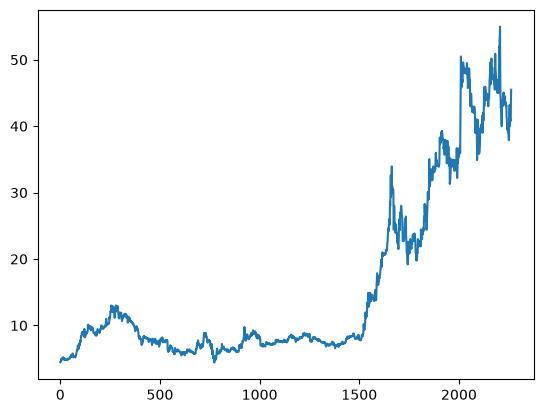

In [2]:
import matplotlib.pyplot as plt

plt.plot(uba['close_price'])
plt.show()

In [3]:
uba_end_month_df = (
    uba
    .sort_values("date")
    .groupby(uba["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

uba_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45380,UBA,2017-01-31,4.77,4.77,3546729,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47202,UBA,2017-02-28,5.00,5.00,23876412,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49318,UBA,2017-03-31,5.77,5.77,22025318,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51146,UBA,2017-04-28,5.82,5.82,15561039,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53068,UBA,2017-05-31,7.50,7.50,34994169,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35382,UBA,2026-03-31,46.40,46.40,15798687,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281208,UBA,2026-04-30,42.75,42.75,88993142,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284274,UBA,2026-05-29,44.35,44.35,8896401,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294202,UBA,2026-06-30,38.40,38.40,9694350,2026-06-30T15:10:03.08168+00:00,6,2,2026


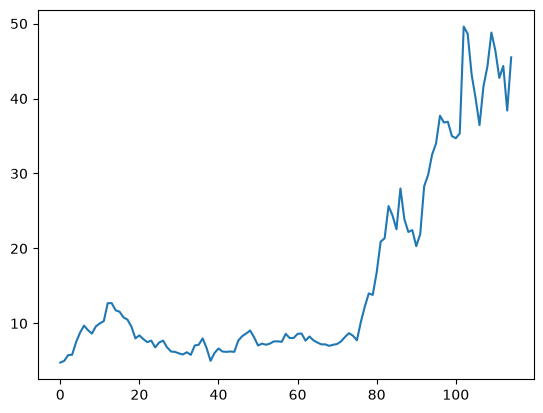

In [4]:
plt.plot(uba_end_month_df['close_price'])
plt.show()

In [5]:
uba_end_month_df['returns']=uba_end_month_df['close_price'].pct_change()*100
uba_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45380,UBA,2017-01-31,4.77,4.77,3546729,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47202,UBA,2017-02-28,5.00,5.00,23876412,2026-04-08T02:44:45.006295+00:00,2,1,2017,4.821803
2,49318,UBA,2017-03-31,5.77,5.77,22025318,2026-04-08T02:45:42.281198+00:00,3,1,2017,15.400000
3,51146,UBA,2017-04-28,5.82,5.82,15561039,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.866551
4,53068,UBA,2017-05-31,7.50,7.50,34994169,2026-04-08T02:52:57.421655+00:00,5,2,2017,28.865979
...,...,...,...,...,...,...,...,...,...,...,...
110,35382,UBA,2026-03-31,46.40,46.40,15798687,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.918033
111,281208,UBA,2026-04-30,42.75,42.75,88993142,2026-04-30T15:00:02.170664+00:00,4,2,2026,-7.866379
112,284274,UBA,2026-05-29,44.35,44.35,8896401,2026-05-29T15:00:02.455558+00:00,5,2,2026,3.742690
113,294202,UBA,2026-06-30,38.40,38.40,9694350,2026-06-30T15:10:03.08168+00:00,6,2,2026,-13.416009


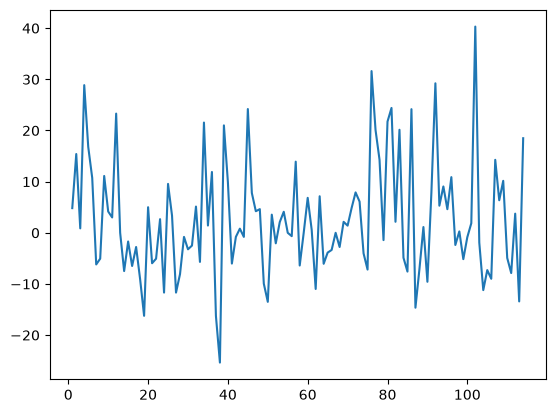

In [6]:
plt.plot(uba_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(uba_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.663454068775511), np.float64(1.334415824215952e-16), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(771.2478190067352))
stationary


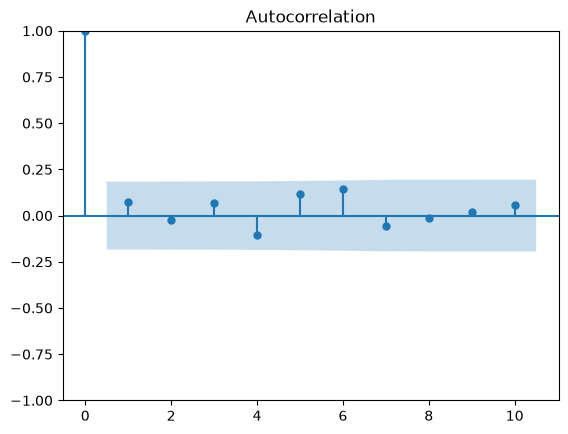

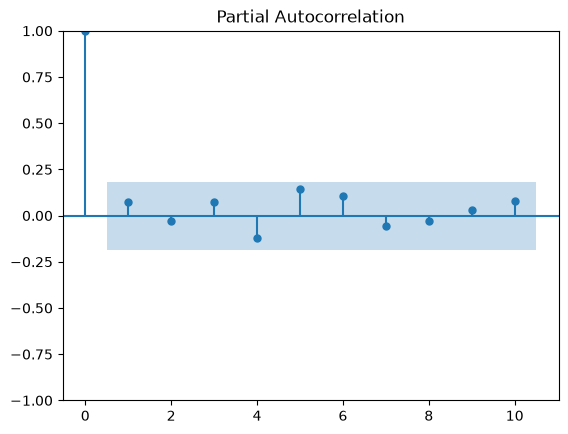

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(uba_end_month_df['returns'].dropna(), lags=10)
plot_pacf(uba_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=uba_end_month_df['close_price'][:-10]
test=uba_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -141.96126678268803]
[0, 0, 0, 0, 0, 1, -51.88769305905826]
[0, 0, 0, 0, 0, 2, -19.9370136914467]
[0, 0, 0, 0, 1, 0, -3.9161227765533955]
[0, 0, 0, 0, 1, 1, -4.742431460346283]
[0, 0, 0, 0, 1, 2, -3.3917202283191807]
[0, 0, 0, 0, 2, 0, -9.325194457988204]
[0, 0, 0, 0, 2, 1, -6.323229698478835]
[0, 0, 0, 0, 2, 2, -9.52810049511033]
[0, 0, 0, 1, 0, 0, -6.072097315818594]
[0, 0, 0, 1, 0, 1, -6.158325999229372]
[0, 0, 0, 1, 0, 2, -4.348045456188113]
[0, 0, 0, 1, 1, 0, -3.341397323004972]
[0, 0, 0, 1, 1, 1, -3.143931292081402]
[0, 0, 0, 1, 1, 2, -3.0480016792557585]
[0, 0, 0, 1, 2, 0, -6.51608497858892]
[0, 0, 0, 1, 2, 1, -6.535507372266055]
[0, 0, 0, 1, 2, 2, -11.410779829034677]
[0, 0, 0, 2, 0, 0, -2.9119209547491707]
[0, 0, 0, 2, 0, 1, -3.8711961848053056]
[0, 0, 0, 2, 0, 2, -4.79214973667261]
[0, 0, 0, 2, 1, 0, -3.1139138874673344]
[0, 0, 0, 2, 1, 1, -3.1904935183076875]
[0, 0, 0, 2, 1, 2, -3.166114493564666]
[0, 0, 0, 2, 2, 0, -6.568585802266523]
[0, 0, 0, 2, 2, 1, -

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-539.124005
177,0,2,0,1,2,0,-527.381019
186,0,2,0,2,2,0,-391.700968
169,0,2,0,0,2,1,-387.344671
165,0,2,0,0,1,0,-328.815074
...,...,...,...,...,...,...,...
567,2,1,0,0,0,0,-0.017227
351,1,1,1,0,0,0,-0.011436
81,0,1,0,0,0,0,-0.008671
324,1,1,0,0,0,0,-0.001026


Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=uba_end_month_df['returns'].dropna()[:-10]
test=uba_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.010169746418958736]
[0, 0, 0, 0, 0, 1, -0.07936890702204558]
[0, 0, 0, 0, 0, 2, -0.13578760289280045]
[0, 0, 0, 0, 1, 0, -0.39260767053589807]
[0, 0, 0, 0, 1, 1, -0.07701497868197538]
[0, 0, 0, 0, 1, 2, -0.16682965740317113]
[0, 0, 0, 0, 2, 0, -6.0197500226226985]
[0, 0, 0, 0, 2, 1, -0.5406561050188432]
[0, 0, 0, 0, 2, 2, -0.38124611020473664]
[0, 0, 0, 1, 0, 0, -0.08857982027306521]
[0, 0, 0, 1, 0, 1, -0.1124634846070951]
[0, 0, 0, 1, 0, 2, -0.12575307523199086]
[0, 0, 0, 1, 1, 0, -0.5521488405738799]
[0, 0, 0, 1, 1, 1, -0.16987031391740492]
[0, 0, 0, 1, 1, 2, -0.14129786562423918]
[0, 0, 0, 1, 2, 0, -1.6764048057141334]
[0, 0, 0, 1, 2, 1, -0.5584064358751102]
[0, 0, 0, 1, 2, 2, -0.20052150534940671]
[0, 0, 0, 2, 0, 0, -0.12568401971125498]
[0, 0, 0, 2, 0, 1, -0.11903318041829447]
[0, 0, 0, 2, 0, 2, -0.2064983763702002]
[0, 0, 0, 2, 1, 0, -0.253508353720149]
[0, 0, 0, 2, 1, 1, -0.17178874085467055]
[0, 0, 0, 2, 1, 2, -0.19636231006539573]
[0, 0, 0, 2, 2, 0, -1.31

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
211,0,2,1,2,1,1,-53759.474028
619,2,1,1,2,2,2,-2678.954269
420,1,2,0,1,2,0,-1268.171204
411,1,2,0,0,2,0,-1235.715800
177,0,2,0,1,2,0,-1174.116447
...,...,...,...,...,...,...,...
513,2,0,1,0,0,0,-0.009614
54,0,0,2,0,0,0,-0.004429
27,0,0,1,0,0,0,0.007840
486,2,0,0,0,0,0,0.010760


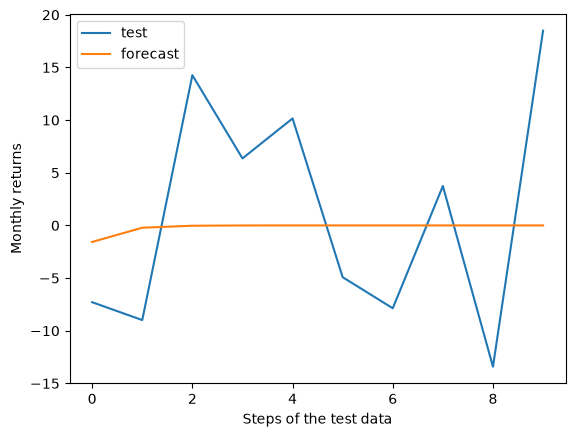

r2_score:  0.011236244957524177
rmse:  10.39090666987235
description:  count    114.000000
mean       2.596546
std       11.341079
min      -25.373134
25%       -5.127611
50%        0.836501
75%        7.859382
max       40.311174
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=uba_end_month_df['returns'].dropna()[:-10]
y_test=uba_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', uba_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
